# Analisis de Data original entregada y comparacin de modelos Implementados: Cai (2015) & Son Road (2000)

In [ ]:
import os
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#lectura de datos
ruta_carp = "/content/drive/MyDrive/ICI/Investigacion/fondecyt/data APIMS"
csv_files = []
if os.path.exists(ruta_carp):
  for item in os.listdir(ruta_carp):
    item_path = os.path.join(ruta_carp, item)
    if os.path.isfile(item_path) and item.endswith('.csv'):
      csv_files.append(item_path)

  csv_files.sort()
  print(f"Se encontraron {len(csv_files)} archivos CSV en '{ruta_carp}':")
  for csv_file in csv_files:
    print(csv_file)
else:
  print(f"ruta '{ruta_carp}' equivocada")

Se encontraron 24 archivos CSV en '/content/drive/MyDrive/ICI/Investigacion/fondecyt/data APIMS':
/content/drive/MyDrive/ICI/Investigacion/fondecyt/data APIMS/hora 00.csv
/content/drive/MyDrive/ICI/Investigacion/fondecyt/data APIMS/hora 01.csv
/content/drive/MyDrive/ICI/Investigacion/fondecyt/data APIMS/hora 02.csv
/content/drive/MyDrive/ICI/Investigacion/fondecyt/data APIMS/hora 03.csv
/content/drive/MyDrive/ICI/Investigacion/fondecyt/data APIMS/hora 04.csv
/content/drive/MyDrive/ICI/Investigacion/fondecyt/data APIMS/hora 05.csv
/content/drive/MyDrive/ICI/Investigacion/fondecyt/data APIMS/hora 06.csv
/content/drive/MyDrive/ICI/Investigacion/fondecyt/data APIMS/hora 07.csv
/content/drive/MyDrive/ICI/Investigacion/fondecyt/data APIMS/hora 08.csv
/content/drive/MyDrive/ICI/Investigacion/fondecyt/data APIMS/hora 09.csv
/content/drive/MyDrive/ICI/Investigacion/fondecyt/data APIMS/hora 10.csv
/content/drive/MyDrive/ICI/Investigacion/fondecyt/data APIMS/hora 11.csv
/content/drive/MyDrive/ICI

In [ ]:
#dfs
dataframes = {}

for csv_file in csv_files:
  nombre = os.path.basename(csv_file)
  df = pd.read_csv(csv_file)
  dataframes[nombre] = df
  print(f"'{nombre}' dentro del HashMap. filas {len(df)}, cols: {df.shape[1]}")

if dataframes:
  first_df_name = list(dataframes.keys())[0]
  print(f"\nVisualizacion de Data x Hora")
  display(dataframes[first_df_name].head())

'hora 00.csv' dentro del HashMap. filas 46283, cols: 20
'hora 01.csv' dentro del HashMap. filas 46283, cols: 20
'hora 02.csv' dentro del HashMap. filas 46283, cols: 20
'hora 03.csv' dentro del HashMap. filas 46283, cols: 20
'hora 04.csv' dentro del HashMap. filas 46283, cols: 20
'hora 05.csv' dentro del HashMap. filas 46283, cols: 20
'hora 06.csv' dentro del HashMap. filas 46283, cols: 20
'hora 07.csv' dentro del HashMap. filas 46283, cols: 20
'hora 08.csv' dentro del HashMap. filas 46283, cols: 20
'hora 09.csv' dentro del HashMap. filas 46283, cols: 20
'hora 10.csv' dentro del HashMap. filas 46283, cols: 20
'hora 11.csv' dentro del HashMap. filas 46283, cols: 20
'hora 12.csv' dentro del HashMap. filas 46283, cols: 20
'hora 13.csv' dentro del HashMap. filas 46283, cols: 20
'hora 14.csv' dentro del HashMap. filas 46283, cols: 20
'hora 15.csv' dentro del HashMap. filas 46283, cols: 20
'hora 16.csv' dentro del HashMap. filas 46283, cols: 20
'hora 17.csv' dentro del HashMap. filas 46283, c

,osm_id,capacidad_lwb,capacidad_upb,highway,id_sntg,name,waterwy,aerilwy,barrier,man_mad,z_order,othr_tg,Velocdd,Relativ,Vel_libre,Largo_km,Costo_Marginal_largo,temp_relac,flow_lwb,flow_upb
0,1000357745,300,600,residential,44287,Gran Via,NaN,NaN,NaN,NaN,3,"""lanes""=>""2"",""oneway""=>""no"",""surface""=>""concrete""",NaN,NaN,NaN,0.172658,NaN,NaN,NaN,NaN
1,1000357746,300,600,residential,44288,Gran Via,NaN,NaN,NaN,NaN,3,"""lanes""=>""1"",""oneway""=>""yes"",""surface""=>""concr...",NaN,NaN,NaN,0.043514,NaN,NaN,NaN,NaN
2,1000357752,300,600,residential,44289,La Rambla,NaN,NaN,NaN,NaN,3,"""lanes""=>""2"",""maxspeed""=>""50"",""oneway""=>""no"",""...",NaN,NaN,NaN,0.048210,NaN,NaN,NaN,NaN
3,1000357756,300,600,residential,44290,Juan Emilio Pacull,NaN,NaN,NaN,NaN,3,"""lanes""=>""2"",""maxspeed""=>""50"",""oneway""=>""no"",""...",NaN,NaN,NaN,0.163090,NaN,NaN,NaN,NaN
4,1000372603,300,600,residential,44291,Anibal Pinto,NaN,NaN,NaN,NaN,3,"""lanes""=>""2"",""surface""=>""concrete""",NaN,NaN,NaN,0.223372,NaN,NaN,NaN,NaN


In [ ]:
#solo df con valores de Velocidad
df_sin_nan = {}

for name, df in dataframes.items():
  if "Velocdd" in df.columns:
    df_limpio = df.dropna(subset=["Velocdd"])
    df_sin_nan[name] = df_limpio
    print(f"DataFrame '{name}': {len(df_limpio)} filas sin NaN en 'Velocdd'.")

if df_sin_nan:
  nombre = list(df_sin_nan.keys())[0]
  print(f"\nVisualizacion de Data x Hora sin NaN")
  display(df_sin_nan[nombre].head())

DataFrame 'hora 00.csv': 17204 filas sin NaN en 'Velocdd'.
DataFrame 'hora 01.csv': 17199 filas sin NaN en 'Velocdd'.
DataFrame 'hora 02.csv': 17203 filas sin NaN en 'Velocdd'.
DataFrame 'hora 03.csv': 17200 filas sin NaN en 'Velocdd'.
DataFrame 'hora 04.csv': 17205 filas sin NaN en 'Velocdd'.
DataFrame 'hora 05.csv': 17205 filas sin NaN en 'Velocdd'.
DataFrame 'hora 06.csv': 17205 filas sin NaN en 'Velocdd'.
DataFrame 'hora 07.csv': 17212 filas sin NaN en 'Velocdd'.
DataFrame 'hora 08.csv': 17276 filas sin NaN en 'Velocdd'.
DataFrame 'hora 09.csv': 17240 filas sin NaN en 'Velocdd'.
DataFrame 'hora 10.csv': 17234 filas sin NaN en 'Velocdd'.
DataFrame 'hora 11.csv': 17207 filas sin NaN en 'Velocdd'.
DataFrame 'hora 12.csv': 17225 filas sin NaN en 'Velocdd'.
DataFrame 'hora 13.csv': 17257 filas sin NaN en 'Velocdd'.
DataFrame 'hora 14.csv': 17213 filas sin NaN en 'Velocdd'.
DataFrame 'hora 15.csv': 17220 filas sin NaN en 'Velocdd'.
DataFrame 'hora 16.csv': 17237 filas sin NaN en 'Velocdd

,osm_id,capacidad_lwb,capacidad_upb,highway,id_sntg,name,waterwy,aerilwy,barrier,man_mad,z_order,othr_tg,Velocdd,Relativ,Vel_libre,Largo_km,Costo_Marginal_largo,temp_relac,flow_lwb,flow_upb
5,1000372605,1600,2400,secondary,17913,Avenida Jose Miguel Infante,NaN,NaN,NaN,NaN,6,"""cycleway:right""=>""track"",""lanes""=>""2"",""motor_...",30.0,1.0,30.0,0.325890,0.0,0.0,0.0,0.0
11,1000372613,600,900,tertiary,17918,Presidente Salvador Allende G.,NaN,NaN,NaN,NaN,4,"""alt_name""=>""Avenida Constanera"",""lanes""=>""2"",...",25.0,1.0,25.0,0.474866,0.0,0.0,0.0,0.0
14,1000372616,1600,2400,secondary,17919,Avenida Jose Miguel Infante,NaN,NaN,NaN,NaN,6,"""cycleway:right""=>""track"",""lanes""=>""2"",""oneway...",30.0,1.0,30.0,0.219098,0.0,0.0,0.0,0.0
18,1000372620,600,900,tertiary,17920,Brasil,NaN,NaN,NaN,NaN,4,"""lanes""=>""2"",""maxspeed""=>""30"",""surface""=>""asph...",30.0,1.0,30.0,0.084552,0.0,0.0,0.0,0.0
19,1000398716,1600,2400,secondary,17921,Avenida Domingo Santa Maria,NaN,NaN,NaN,NaN,6,"""busway:right""=>""lane"",""lanes""=>""2"",""maxspeed""...",30.0,1.0,30.0,0.189894,0.0,0.0,0.0,0.0


In [ ]:
#modelos de prediccion de ruido

#modelo suizo
def Lx_truck (vel: float,
              delta_s: float = 0,
              delta_BG: float = 0) -> float:
  termino1 = 10 ** (0.1 * (16.3 + 35 * np.log10(vel)))
  termino2 = 10**(0.1 * (74.7 + 10*np.log10(1 + ((vel/56)**3.5) + delta_s)))
  return 28.5 + 10 * np.log10(termino1 + termino2) + delta_BG

#modelo Cai Leq
def L0(v_kmh: float,
             tam: str = "large") -> float:
  V = np.maximum(v_kmh, 1e-3)
  if (tam == "large"):
    return 38.10 * np.log10(V) + 18.00
  elif(tam == "medium"):
    return 43.70 * np.log10(V) + 4.80
  else:
    return 33.66 * np.log10(V) + 12.60

#modelo Cai Leq
def Leq_linea_heavy(vel: float,
                    q: float,
                    r0: float = 1.0,
                    r: float = 10.0,
                    alpha: float = 0.0,
                    C0_db: float = 0.0,
                    tam: str = "large") -> float:
  Loi = L0(vel, tam)
  V = np.maximum(vel, 1e-3)
  termino1 = 10 * np.log10(q/vel)
  termino2 = np.log((r0/r) ** (1 + alpha))
  termino2_1 = 10 * np.log10(abs(termino2))
  termino3 = 10 * np.log10(np.pi * r0)
  return Loi + termino1 + termino2 + termino3 + C0_db

In [ ]:
filtered_data_by_osm_id = {}
target_osm_id = 698094033

print(f"Filtrando DataFrames por osm_id = {target_osm_id}\n")

for name, df in df_sin_nan.items():
  df_filtered = df[df['osm_id'] == target_osm_id]
  if not df_filtered.empty:
    filtered_data_by_osm_id[name] = df_filtered
    print(f"DataFrame '{name}': {len(df_filtered)} filas encontradas para osm_id {target_osm_id}.")
  else:
    print(f"DataFrame '{name}': No se encontraron filas para osm_id {target_osm_id}.")

if filtered_data_by_osm_id:
  first_filtered_df_name = list(filtered_data_by_osm_id.keys())[0]
  print(f"\nVisualización del primer DataFrame filtrado ('{first_filtered_df_name}'):")
  display(filtered_data_by_osm_id[first_filtered_df_name].head())

Filtrando DataFrames por osm_id = 698094033

DataFrame 'hora 00.csv': 1 filas encontradas para osm_id 698094033.
DataFrame 'hora 01.csv': 1 filas encontradas para osm_id 698094033.
DataFrame 'hora 02.csv': 1 filas encontradas para osm_id 698094033.
DataFrame 'hora 03.csv': 1 filas encontradas para osm_id 698094033.
DataFrame 'hora 04.csv': 1 filas encontradas para osm_id 698094033.
DataFrame 'hora 05.csv': 1 filas encontradas para osm_id 698094033.
DataFrame 'hora 06.csv': 1 filas encontradas para osm_id 698094033.
DataFrame 'hora 07.csv': 1 filas encontradas para osm_id 698094033.
DataFrame 'hora 08.csv': 1 filas encontradas para osm_id 698094033.
DataFrame 'hora 09.csv': 1 filas encontradas para osm_id 698094033.
DataFrame 'hora 10.csv': 1 filas encontradas para osm_id 698094033.
DataFrame 'hora 11.csv': 1 filas encontradas para osm_id 698094033.
DataFrame 'hora 12.csv': 1 filas encontradas para osm_id 698094033.
DataFrame 'hora 13.csv': 1 filas encontradas para osm_id 698094033.
Dat

,osm_id,capacidad_lwb,capacidad_upb,highway,id_sntg,name,waterwy,aerilwy,barrier,man_mad,z_order,othr_tg,Velocdd,Relativ,Vel_libre,Largo_km,Costo_Marginal_largo,temp_relac,flow_lwb,flow_upb
35866,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,9,"""alt_name""=>""Autopista del Sol"",""bicycle""=>""no...",87.413793,0.97131,89.99574,0.411955,0.000541,0.348606,2300.796815,2509.960162


In [ ]:
all_hourly_data = []

for name, df in filtered_data_by_osm_id.items():
  hour_str = name.replace('hora ', '').replace('.csv', '')
  hour = int(hour_str)

  if not df.empty:
    df_with_hour = df.copy()
    df_with_hour['hour'] = hour
    all_hourly_data.append(df_with_hour)
  else:
    print(f"Advertencia: No se encontraron datos para osm_id {target_osm_id} en {name}.")

if all_hourly_data:
  full_hourly_summary_df = pd.concat(all_hourly_data, ignore_index=True)

  full_hourly_summary_df = full_hourly_summary_df.sort_values(by='hour').reset_index(drop=True)

  print(f"Tabla completa con 24 observaciones horarias para osm_id {target_osm_id}:")
  display(full_hourly_summary_df)
else:
  print(f"No se pudieron consolidar los datos. No se encontraron filas para osm_id {target_osm_id} en ningùn DataFrame.")

Tabla completa con 24 observaciones horarias para osm_id 698094033:


,osm_id,capacidad_lwb,capacidad_upb,highway,id_sntg,name,waterwy,aerilwy,barrier,man_mad,...,othr_tg,Velocdd,Relativ,Vel_libre,Largo_km,Costo_Marginal_largo,temp_relac,flow_lwb,flow_upb,hour
0,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,"""alt_name""=>""Autopista del Sol"",""bicycle""=>""no...",87.413793,0.971310,89.995740,0.411955,0.000541,0.348606,2300.796815,2509.960162,0
1,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,"""alt_name""=>""Autopista del Sol"",""bicycle""=>""no...",88.793103,1.000000,88.793103,0.411955,0.000000,0.000000,0.000000,0.000000,1
2,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,"""alt_name""=>""Autopista del Sol"",""bicycle""=>""no...",88.793103,1.000000,88.793103,0.411955,0.000000,0.000000,0.000000,0.000000,2
3,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,"""alt_name""=>""Autopista del Sol"",""bicycle""=>""no...",88.793103,1.000000,88.793103,0.411955,0.000000,0.000000,0.000000,0.000000,3
4,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,"""alt_name""=>""Autopista del Sol"",""bicycle""=>""no...",88.793103,1.000000,88.793103,0.411955,0.000000,0.000000,0.000000,0.000000,4
5,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,"""alt_name""=>""Autopista del Sol"",""bicycle""=>""no...",88.793103,1.000000,88.793103,0.411955,0.000000,0.000000,0.000000,0.000000,5
6,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,"""alt_name""=>""Autopista del Sol"",""bicycle""=>""no...",88.793103,1.000000,88.793103,0.411955,0.000000,0.000000,0.000000,0.000000,6
7,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,"""alt_name""=>""Autopista del Sol"",""bicycle""=>""no...",88.793103,1.000000,88.793103,0.411955,0.000000,0.000000,0.000000,0.000000,7
8,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,"""alt_name""=>""Autopista del Sol"",""bicycle""=>""no...",88.793103,1.000000,88.793103,0.411955,0.000000,0.000000,0.000000,0.000000,8
9,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,"""alt_name""=>""Autopista del Sol"",""bicycle""=>""no...",88.793103,1.000000,88.793103,0.411955,0.000000,0.000000,0.000000,0.000000,9


In [ ]:
# Aplicar la condición para actualizar flow_lwb y flow_upb
# Cuando Relativ es igual a 1, reemplazar flow_lwb con capacidad_lwb y flow_upb con capacidad_upb
condition = full_hourly_summary_df['Relativ'] == 1

# Contar los valores antes
initial_flow_lwb_count = full_hourly_summary_df.loc[condition, 'flow_lwb'].count()
initial_flow_upb_count = full_hourly_summary_df.loc[condition, 'flow_upb'].count()

# Aplicar la actualización
full_hourly_summary_df.loc[condition, 'flow_lwb'] = full_hourly_summary_df.loc[condition, 'capacidad_lwb']
full_hourly_summary_df.loc[condition, 'flow_upb'] = full_hourly_summary_df.loc[condition, 'capacidad_upb']

# Contar valores fueron reemplazados
replaced_count_lwb = full_hourly_summary_df.loc[condition].shape[0]
replaced_count_upb = full_hourly_summary_df.loc[condition].shape[0]

print("DataFrame actualizado con la lpgica de congestion:")
display(full_hourly_summary_df)

print(f"\nSe reemplazaron {replaced_count_lwb} valores en 'flow_lwb' donde 'Relativ' era 1.")
print(f"Se reemplazaron {replaced_count_upb} valores en 'flow_upb' donde 'Relativ' era 1.")

DataFrame actualizado con la lógica de congestión:


,osm_id,capacidad_lwb,capacidad_upb,highway,id_sntg,name,waterwy,aerilwy,barrier,man_mad,...,Vel_libre,Largo_km,Costo_Marginal_largo,temp_relac,flow_lwb,flow_upb,hour,suizo,cai_lwb,cai_upb
0,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,89.995740,0.411955,0.000541,0.348606,2300.796815,2509.960162,0,114.896353,108.846093,109.223979
1,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,88.793103,0.411955,0.000000,0.000000,6600.000000,7200.000000,1,115.118629,113.613810,113.991695
2,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,88.793103,0.411955,0.000000,0.000000,6600.000000,7200.000000,2,115.118629,113.613810,113.991695
3,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,88.793103,0.411955,0.000000,0.000000,6600.000000,7200.000000,3,115.118629,113.613810,113.991695
4,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,88.793103,0.411955,0.000000,0.000000,6600.000000,7200.000000,4,115.118629,113.613810,113.991695
5,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,88.793103,0.411955,0.000000,0.000000,6600.000000,7200.000000,5,115.118629,113.613810,113.991695
6,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,88.793103,0.411955,0.000000,0.000000,6600.000000,7200.000000,6,115.118629,113.613810,113.991695
7,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,88.793103,0.411955,0.000000,0.000000,6600.000000,7200.000000,7,115.118629,113.613810,113.991695
8,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,88.793103,0.411955,0.000000,0.000000,6600.000000,7200.000000,8,115.118629,113.613810,113.991695
9,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,88.793103,0.411955,0.000000,0.000000,6600.000000,7200.000000,9,115.118629,113.613810,113.991695



Se reemplazaron 21 valores en 'flow_lwb' donde 'Relativ' era 1.
Se reemplazaron 21 valores en 'flow_upb' donde 'Relativ' era 1.


In [ ]:
# Calculo Suizo
full_hourly_summary_df['suizo'] = full_hourly_summary_df['Velocdd'].apply(Lx_truck)

# Calcular Cai lwb
full_hourly_summary_df['cai_lwb'] = full_hourly_summary_df.apply(
    lambda row: Leq_linea_heavy(vel=row['Velocdd'], q=row['flow_lwb']),
    axis=1
)

# Calcular Cai upb
full_hourly_summary_df['cai_upb'] = full_hourly_summary_df.apply(
    lambda row: Leq_linea_heavy(vel=row['Velocdd'], q=row['flow_upb']),
    axis=1
)

print("df actualizado con los niveles sonoros calculados:")
display(full_hourly_summary_df.head())

DataFrame actualizado con los niveles sonoros calculados:


,osm_id,capacidad_lwb,capacidad_upb,highway,id_sntg,name,waterwy,aerilwy,barrier,man_mad,...,Vel_libre,Largo_km,Costo_Marginal_largo,temp_relac,flow_lwb,flow_upb,hour,suizo,cai_lwb,cai_upb
0,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,89.995740,0.411955,0.000541,0.348606,2300.796815,2509.960162,0,114.896353,108.846093,109.223979
1,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,88.793103,0.411955,0.000000,0.000000,6600.000000,7200.000000,1,115.118629,113.613810,113.991695
2,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,88.793103,0.411955,0.000000,0.000000,6600.000000,7200.000000,2,115.118629,113.613810,113.991695
3,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,88.793103,0.411955,0.000000,0.000000,6600.000000,7200.000000,3,115.118629,113.613810,113.991695
4,698094033,6600,7200,motorway,12638,Ruta 78,NaN,NaN,NaN,NaN,...,88.793103,0.411955,0.000000,0.000000,6600.000000,7200.000000,4,115.118629,113.613810,113.991695


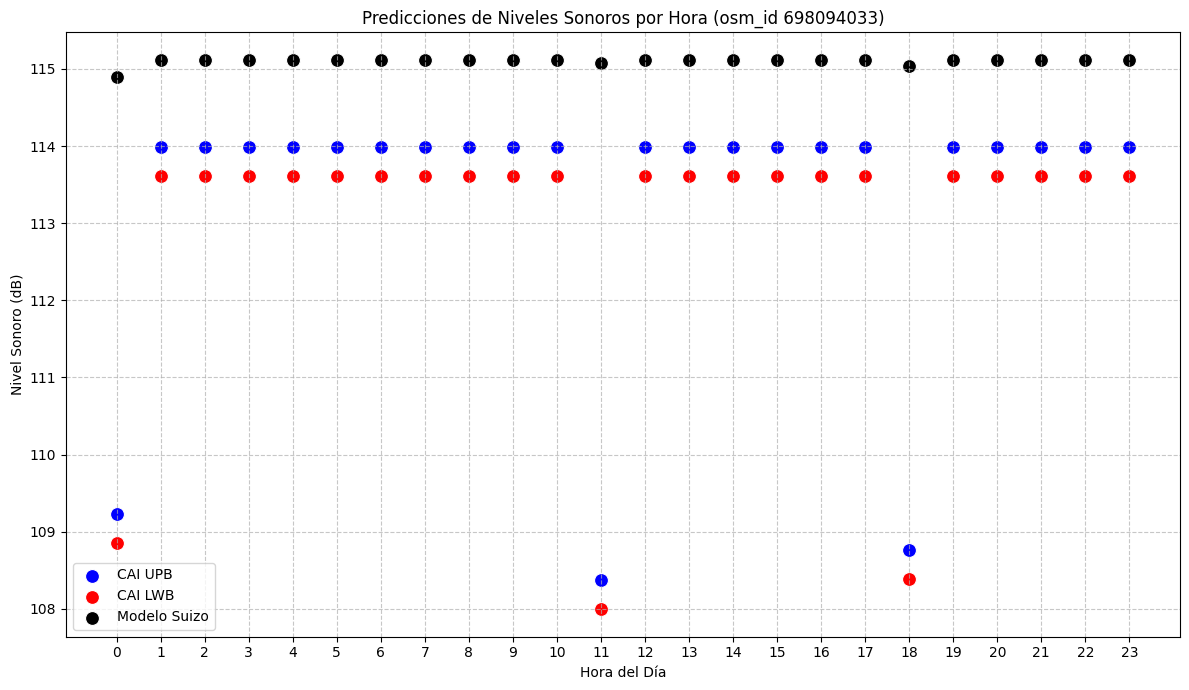

In [ ]:
plt.figure(figsize=(12, 7))

sns.scatterplot(data=full_hourly_summary_df, x='hour', y='cai_upb', color='blue', label='CAI UPB', s=100)
sns.scatterplot(data=full_hourly_summary_df, x='hour', y='cai_lwb', color='red', label='CAI LWB', s=100)
sns.scatterplot(data=full_hourly_summary_df, x='hour', y='suizo', color='black', label='Modelo Suizo', s=100)

plt.title('Predicciones de Niveles Sonoros por Hora (osm_id 698094033)')
plt.xlabel('Hora del Día')
plt.ylabel('Nivel Sonoro (dB)')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#automatizacion de scatterplots
target_osm_ids = [1000372605, 1000372616, 1000372620, 698094033, 187747767, 222646082, 294198701, 368759060,
                  445822779, 447300510, 487167886, 623178011, 58361454, ]

print(f"Lista de osm_ids a analizar: {target_osm_ids}")

Lista de OSM IDs a analizar: [1000372605, 1000372616, 1000372620, 698094033, 187747767, 222646082, 294198701, 368759060, 445822779, 447300510, 487167886, 623178011, 58361454]


In [ ]:
all_results = {}

for current_osm_id in target_osm_ids:
  print(f"\nOsm_id: {current_osm_id}")
  filtered_data_for_current_osm_id = {}

  for name, df in df_sin_nan.items():
    df_filtered = df[df['osm_id'] == current_osm_id]
    if not df_filtered.empty:
      filtered_data_for_current_osm_id[name] = df_filtered

  # Ver si encontraron datos para el osm_id actual
  if not filtered_data_for_current_osm_id:
    print(f"No se encontraron datos para el osm_id {current_osm_id}")
    continue

  all_hourly_data_for_current_osm_id = []
  for name, df in filtered_data_for_current_osm_id.items():
    hour_str = name.replace('hora ', '').replace('.csv', '')
    hour = int(hour_str)
    df_with_hour = df.copy()
    df_with_hour['hour'] = hour
    all_hourly_data_for_current_osm_id.append(df_with_hour)

  full_hourly_summary_df_current = pd.concat(all_hourly_data_for_current_osm_id, ignore_index=True)
  full_hourly_summary_df_current = full_hourly_summary_df_current.sort_values(by='hour').reset_index(drop=True)

  #print(f"{len(full_hourly_summary_df_current)} filas (hrs) para osm_id {current_osm_id}:")
  #display(full_hourly_summary_df_current.head())

  #aplicar reletiva == 1 --> flow == capacidad
  condition_current = full_hourly_summary_df_current['Relativ'] == 1
  full_hourly_summary_df_current.loc[condition_current, 'flow_lwb'] = full_hourly_summary_df_current.loc[condition_current, 'capacidad_lwb']
  full_hourly_summary_df_current.loc[condition_current, 'flow_upb'] = full_hourly_summary_df_current.loc[condition_current, 'capacidad_upb']

  #print(f"df con logica de congestion (?) para osm_id {current_osm_id}:")
  #display(full_hourly_summary_df_current.head())

  # Calculo de presiones de sonido
  full_hourly_summary_df_current['suizo'] = full_hourly_summary_df_current['Velocdd'].apply(Lx_truck)
  full_hourly_summary_df_current['cai_lwb'] = full_hourly_summary_df_current.apply(
      lambda row: Leq_linea_heavy(vel=row['Velocdd'], q=row['flow_lwb']), axis=1)
  full_hourly_summary_df_current['cai_upb'] = full_hourly_summary_df_current.apply(
      lambda row: Leq_linea_heavy(vel=row['Velocdd'], q=row['flow_upb']), axis=1)

  print(f"df con los niveles de ruido (Cai-Suizo) calculados para osm_id {current_osm_id}:")
  display(full_hourly_summary_df_current.head())

  all_results[current_osm_id] = full_hourly_summary_df_current


Osm_id: 1000372605
df con los niveles de ruido (Cai-Suizo) calculados para osm_id 1000372605:


,osm_id,capacidad_lwb,capacidad_upb,highway,id_sntg,name,waterwy,aerilwy,barrier,man_mad,...,Vel_libre,Largo_km,Costo_Marginal_largo,temp_relac,flow_lwb,flow_upb,hour,suizo,cai_lwb,cai_upb
0,1000372605,1600,2400,secondary,17913,Avenida Jose Miguel Infante,NaN,NaN,NaN,NaN,...,30.0,0.32589,0.0,0.0,1600.0,2400.0,0,104.42638,94.217221,95.978133
1,1000372605,1600,2400,secondary,17913,Avenida Jose Miguel Infante,NaN,NaN,NaN,NaN,...,30.0,0.32589,0.0,0.0,1600.0,2400.0,1,104.42638,94.217221,95.978133
2,1000372605,1600,2400,secondary,17913,Avenida Jose Miguel Infante,NaN,NaN,NaN,NaN,...,30.0,0.32589,0.0,0.0,1600.0,2400.0,2,104.42638,94.217221,95.978133
3,1000372605,1600,2400,secondary,17913,Avenida Jose Miguel Infante,NaN,NaN,NaN,NaN,...,30.0,0.32589,0.0,0.0,1600.0,2400.0,3,104.42638,94.217221,95.978133
4,1000372605,1600,2400,secondary,17913,Avenida Jose Miguel Infante,NaN,NaN,NaN,NaN,...,30.0,0.32589,0.0,0.0,1600.0,2400.0,4,104.42638,94.217221,95.978133



Osm_id: 1000372616
df con los niveles de ruido (Cai-Suizo) calculados para osm_id 1000372616:


,osm_id,capacidad_lwb,capacidad_upb,highway,id_sntg,name,waterwy,aerilwy,barrier,man_mad,...,Vel_libre,Largo_km,Costo_Marginal_largo,temp_relac,flow_lwb,flow_upb,hour,suizo,cai_lwb,cai_upb
0,1000372616,1600,2400,secondary,17919,Avenida Jose Miguel Infante,NaN,NaN,NaN,NaN,...,30.0,0.219098,0.0,0.0,1600.0,2400.0,0,104.42638,94.217221,95.978133
1,1000372616,1600,2400,secondary,17919,Avenida Jose Miguel Infante,NaN,NaN,NaN,NaN,...,30.0,0.219098,0.0,0.0,1600.0,2400.0,1,104.42638,94.217221,95.978133
2,1000372616,1600,2400,secondary,17919,Avenida Jose Miguel Infante,NaN,NaN,NaN,NaN,...,30.0,0.219098,0.0,0.0,1600.0,2400.0,2,104.42638,94.217221,95.978133
3,1000372616,1600,2400,secondary,17919,Avenida Jose Miguel Infante,NaN,NaN,NaN,NaN,...,30.0,0.219098,0.0,0.0,1600.0,2400.0,3,104.42638,94.217221,95.978133
4,1000372616,1600,2400,secondary,17919,Avenida Jose Miguel Infante,NaN,NaN,NaN,NaN,...,30.0,0.219098,0.0,0.0,1600.0,2400.0,4,104.42638,94.217221,95.978133



Osm_id: 1000372620
df con los niveles de ruido (Cai-Suizo) calculados para osm_id 1000372620:


...

,osm_id,capacidad_lwb,capacidad_upb,highway,id_sntg,name,waterwy,aerilwy,barrier,man_mad,...,Vel_libre,Largo_km,Costo_Marginal_largo,temp_relac,flow_lwb,flow_upb,hour,suizo,cai_lwb,cai_upb
0,445822779,1600,2400,primary,7706,Avenida Domingo Tocornal,NaN,NaN,NaN,NaN,...,NaN,0.083241,NaN,NaN,NaN,NaN,0,104.305161,NaN,NaN
1,445822779,1600,2400,primary,7706,Avenida Domingo Tocornal,NaN,NaN,NaN,NaN,...,NaN,0.083241,NaN,NaN,NaN,NaN,1,104.305161,NaN,NaN
2,445822779,1600,2400,primary,7706,Avenida Domingo Tocornal,NaN,NaN,NaN,NaN,...,NaN,0.083241,NaN,NaN,NaN,NaN,2,104.305161,NaN,NaN
3,445822779,1600,2400,primary,7706,Avenida Domingo Tocornal,NaN,NaN,NaN,NaN,...,NaN,0.083241,NaN,NaN,NaN,NaN,3,104.305161,NaN,NaN
4,445822779,1600,2400,primary,7706,Avenida Domingo Tocornal,NaN,NaN,NaN,NaN,...,NaN,0.083241,NaN,NaN,NaN,NaN,4,104.305161,NaN,NaN



Osm_id: 447300510
No se encontraron datos para el osm_id 447300510

Osm_id: 487167886
No se encontraron datos para el osm_id 487167886

Osm_id: 623178011
df con los niveles de ruido (Cai-Suizo) calculados para osm_id 623178011:


,osm_id,capacidad_lwb,capacidad_upb,highway,id_sntg,name,waterwy,aerilwy,barrier,man_mad,...,Vel_libre,Largo_km,Costo_Marginal_largo,temp_relac,flow_lwb,flow_upb,hour,suizo,cai_lwb,cai_upb
0,623178011,1600,2400,secondary,11409,San Eugenio,NaN,NaN,NaN,NaN,...,24.444444,0.18253,0.0,0.0,1600.0,2400.0,0,103.842085,91.717976,93.478889
1,623178011,1600,2400,secondary,11409,San Eugenio,NaN,NaN,NaN,NaN,...,24.444444,0.18253,0.0,0.0,1600.0,2400.0,1,103.842085,91.717976,93.478889
2,623178011,1600,2400,secondary,11409,San Eugenio,NaN,NaN,NaN,NaN,...,24.444444,0.18253,0.0,0.0,1600.0,2400.0,2,103.842085,91.717976,93.478889
3,623178011,1600,2400,secondary,11409,San Eugenio,NaN,NaN,NaN,NaN,...,24.444444,0.18253,0.0,0.0,1600.0,2400.0,3,103.842085,91.717976,93.478889
4,623178011,1600,2400,secondary,11409,San Eugenio,NaN,NaN,NaN,NaN,...,24.444444,0.18253,0.0,0.0,1600.0,2400.0,4,103.842085,91.717976,93.478889



Osm_id: 58361454
df con los niveles de ruido (Cai-Suizo) calculados para osm_id 58361454:


,osm_id,capacidad_lwb,capacidad_upb,highway,id_sntg,name,waterwy,aerilwy,barrier,man_mad,...,Vel_libre,Largo_km,Costo_Marginal_largo,temp_relac,flow_lwb,flow_upb,hour,suizo,cai_lwb,cai_upb
0,58361454,1600,2400,secondary,2908,Avenida Salvador,NaN,NaN,NaN,NaN,...,31.089978,0.032621,0.000408,0.469638,751.420916,1127.131375,0,104.228204,90.237311,91.998224
1,58361454,1600,2400,secondary,2908,Avenida Salvador,NaN,NaN,NaN,NaN,...,30.000000,0.032621,0.000000,0.000000,1600.000000,2400.000000,1,104.426380,94.217221,95.978133
2,58361454,1600,2400,secondary,2908,Avenida Salvador,NaN,NaN,NaN,NaN,...,30.000000,0.032621,0.000000,0.000000,1600.000000,2400.000000,2,104.426380,94.217221,95.978133
3,58361454,1600,2400,secondary,2908,Avenida Salvador,NaN,NaN,NaN,NaN,...,30.000000,0.032621,0.000000,0.000000,1600.000000,2400.000000,3,104.426380,94.217221,95.978133
4,58361454,1600,2400,secondary,2908,Avenida Salvador,NaN,NaN,NaN,NaN,...,30.000000,0.032621,0.000000,0.000000,1600.000000,2400.000000,4,104.426380,94.217221,95.978133


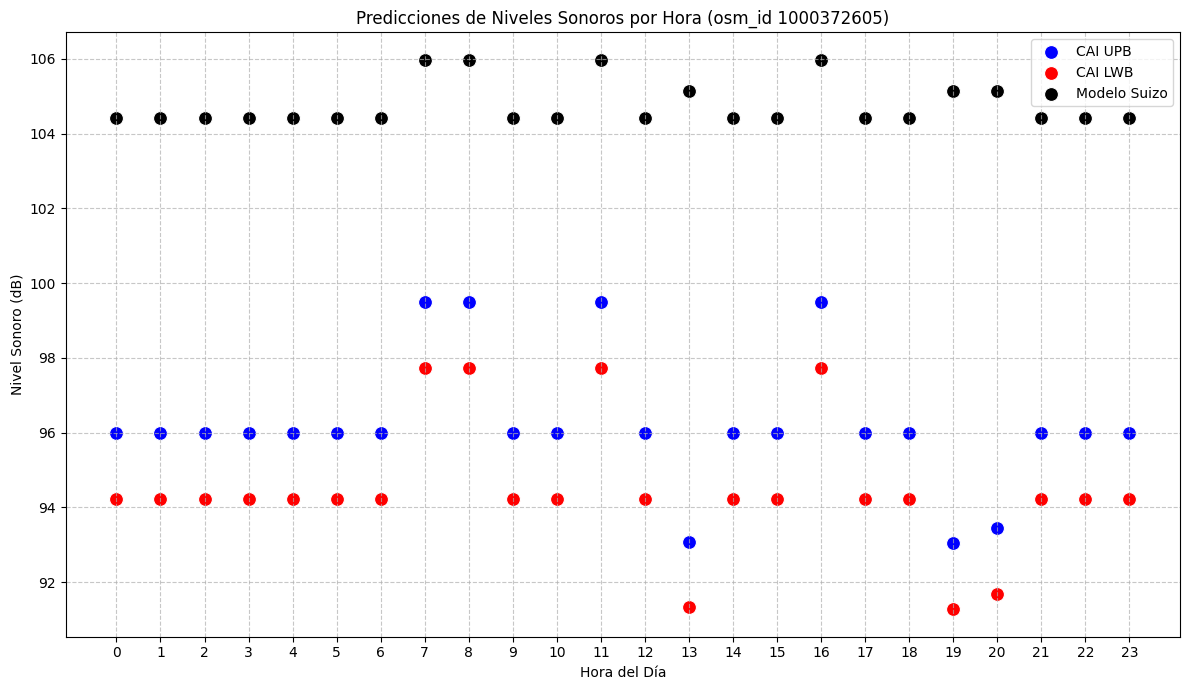

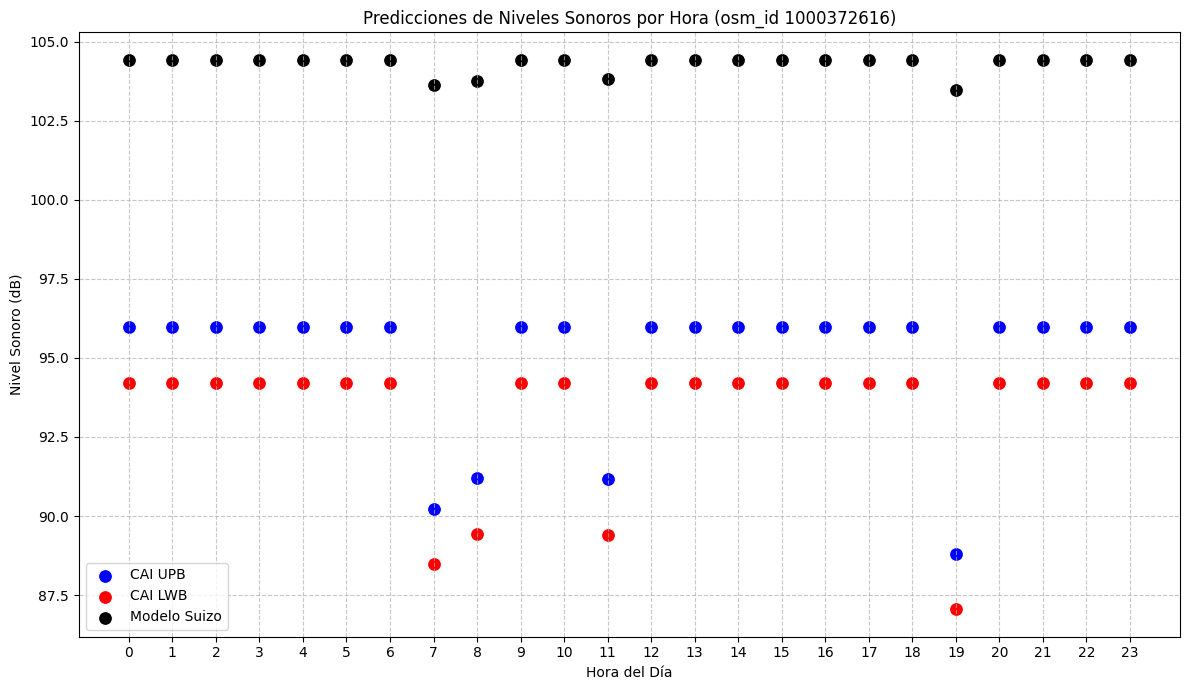

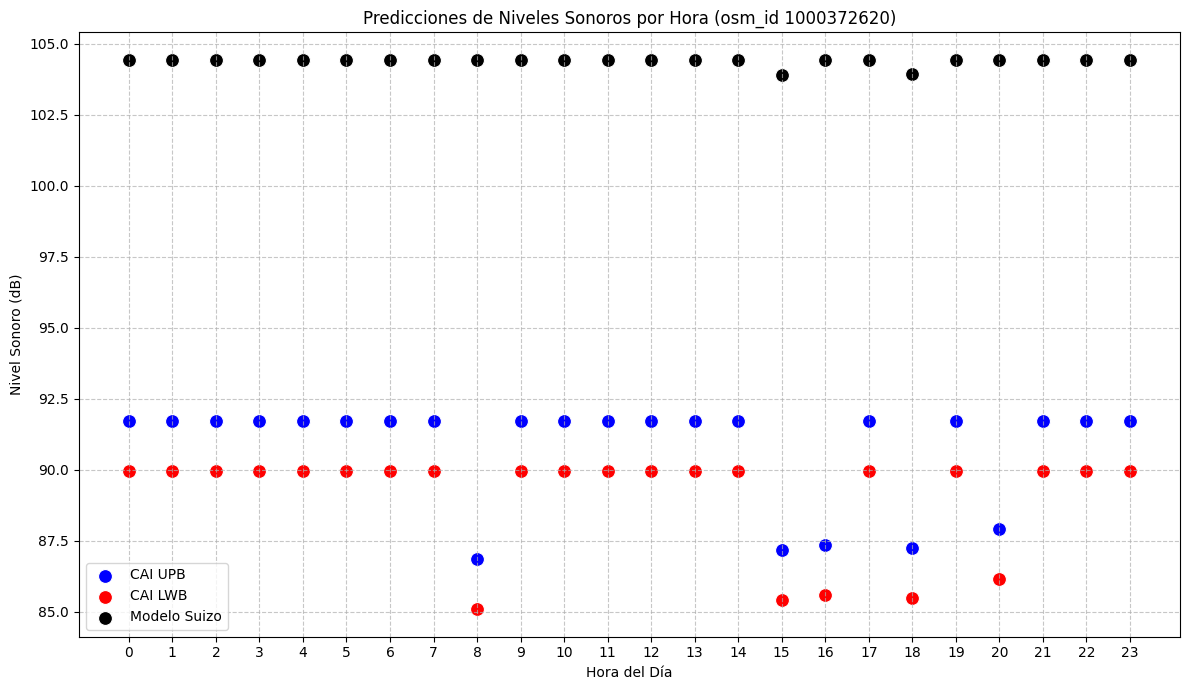

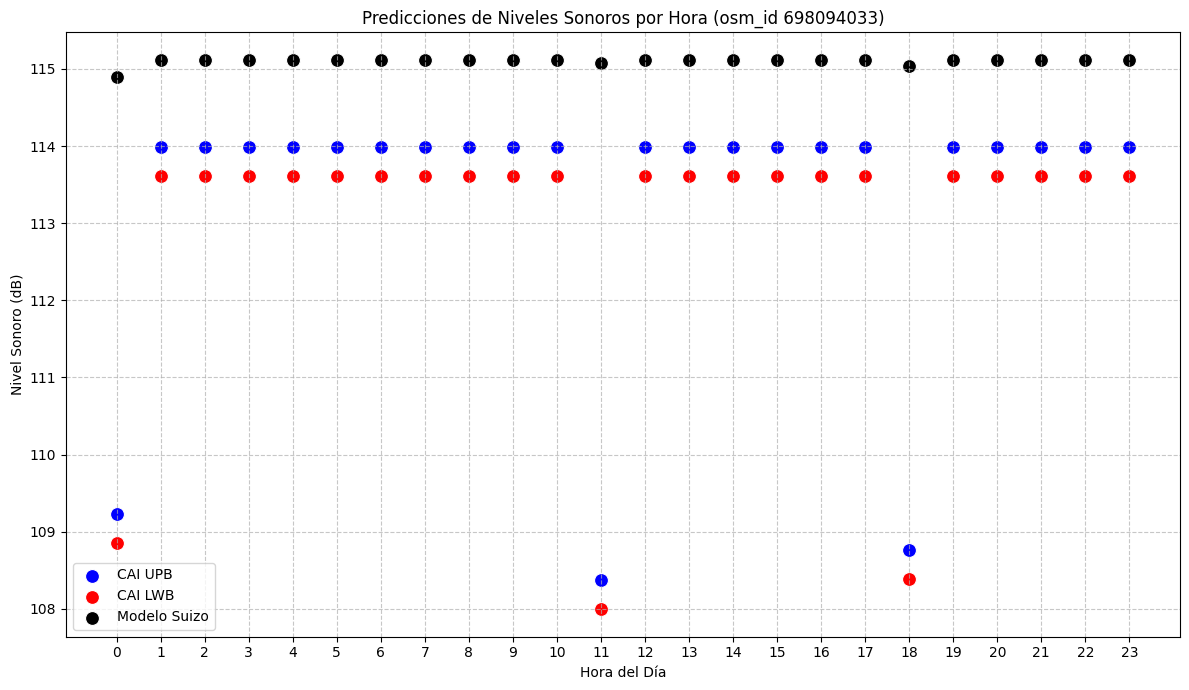

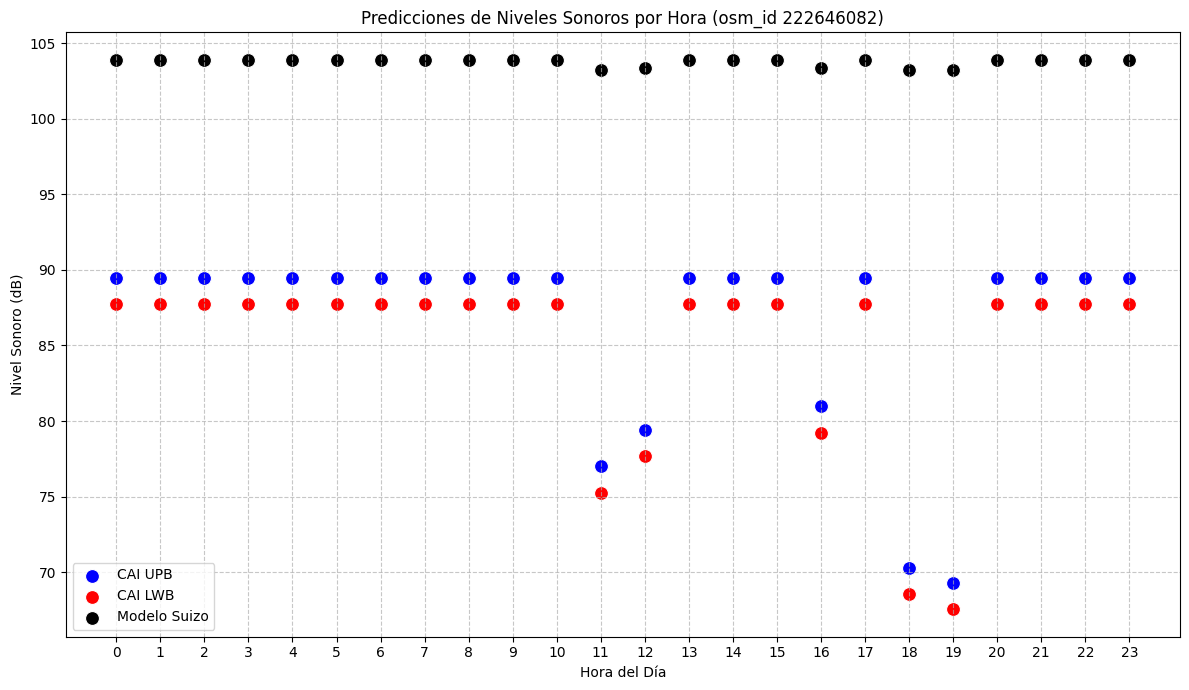

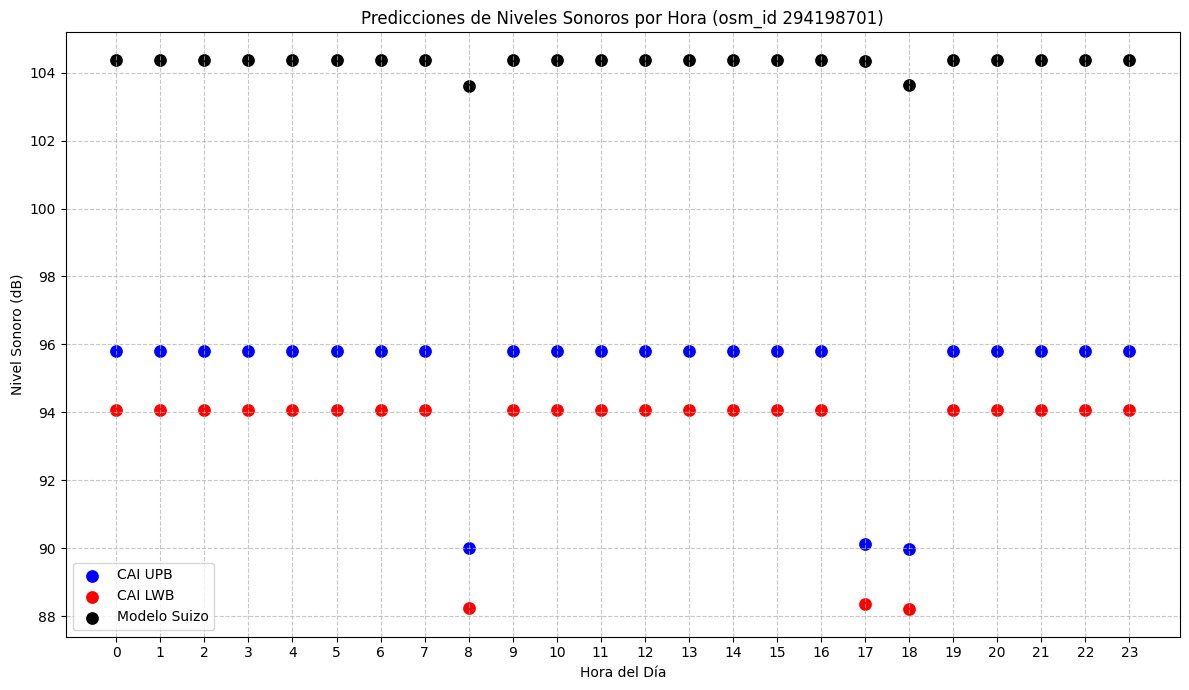

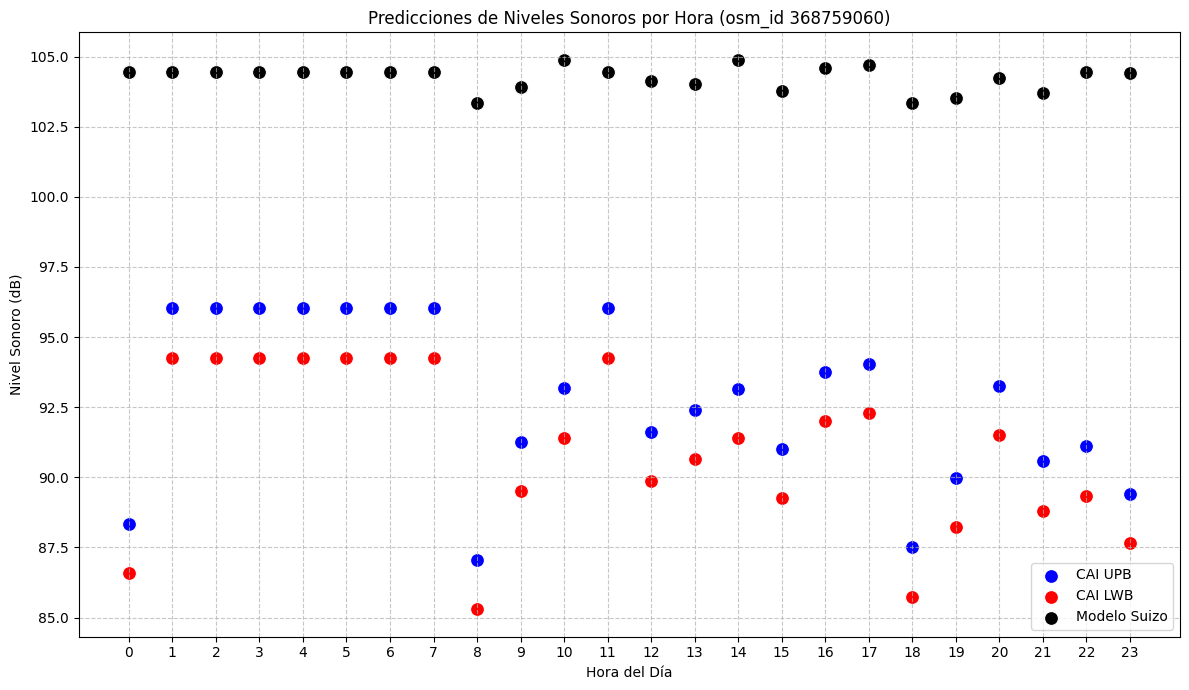

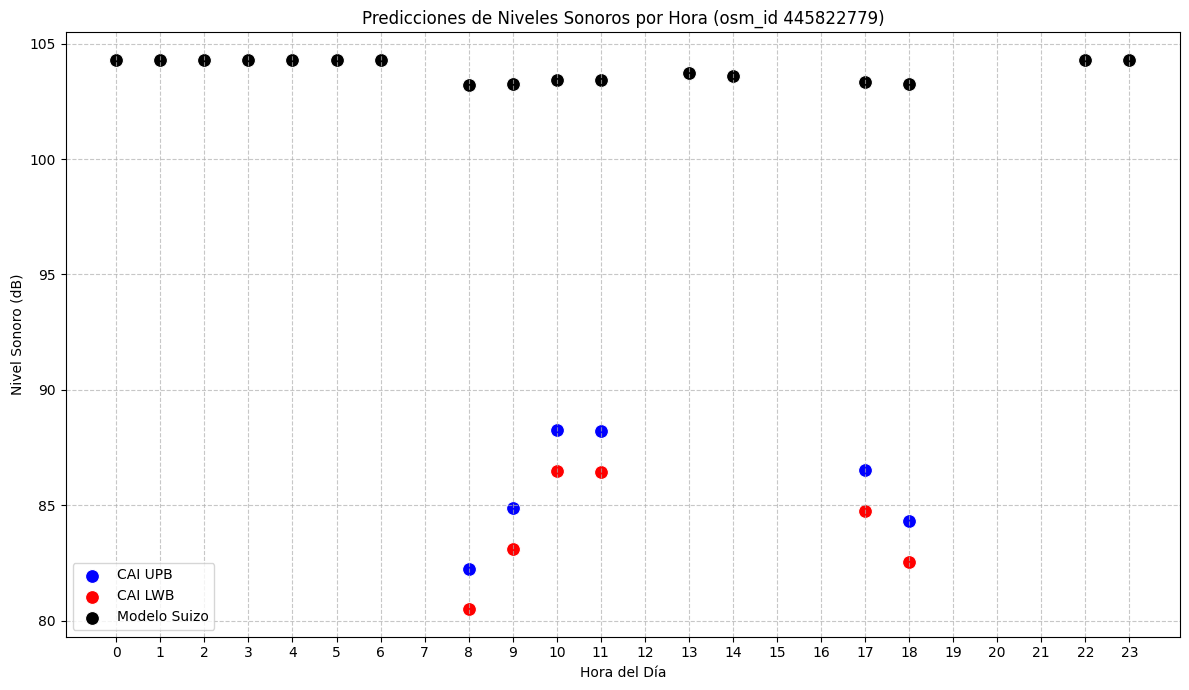

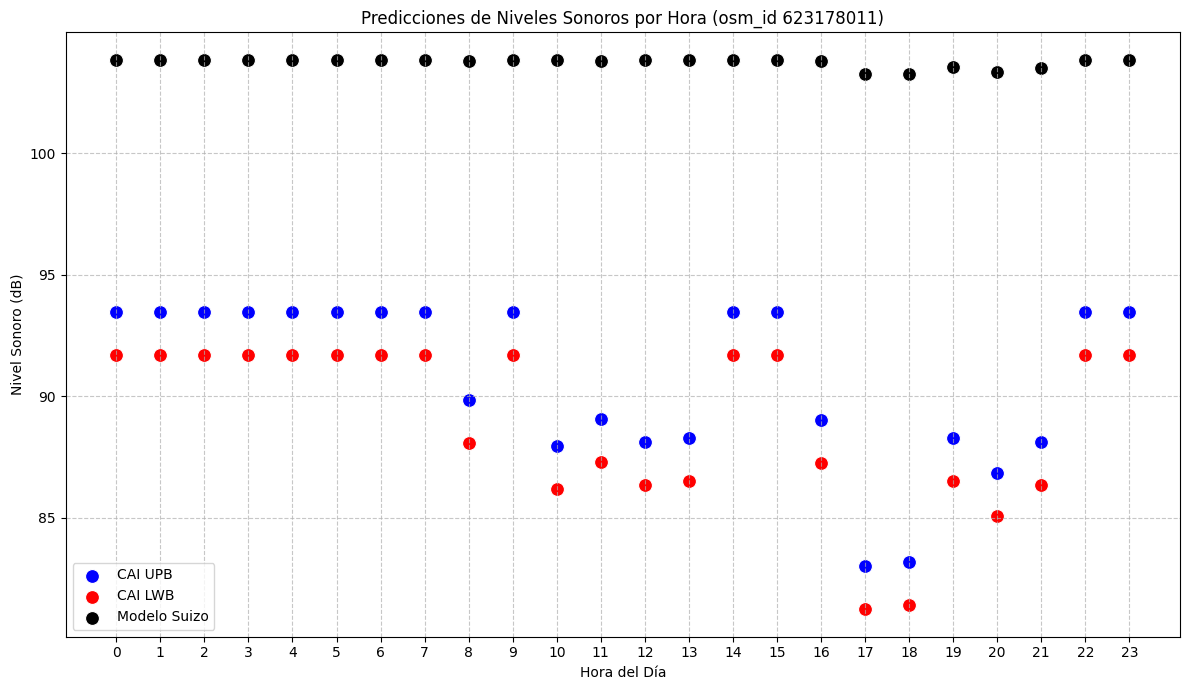

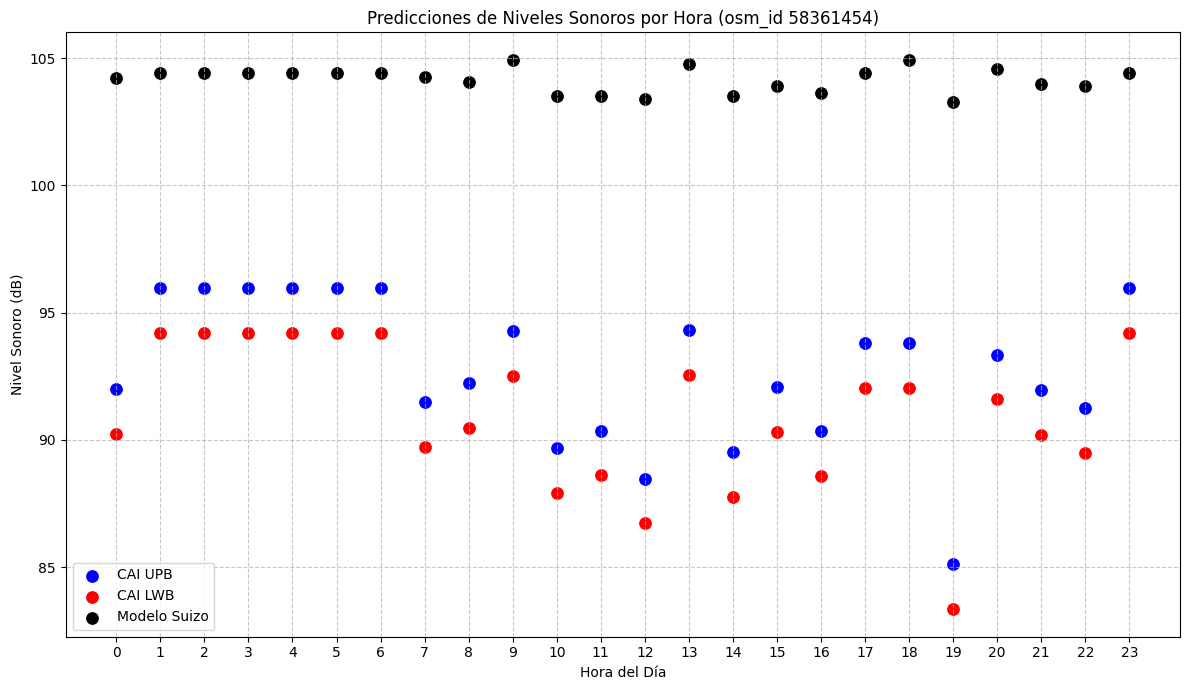

In [ ]:
#scatterplots Suizo vs Cai en ids
for osm_id, df_result in all_results.items():
  plt.figure(figsize=(12, 7))

  sns.scatterplot(data=df_result, x='hour', y='cai_upb', color='blue', label='CAI UPB', s=100)
  sns.scatterplot(data=df_result, x='hour', y='cai_lwb', color='red', label='CAI LWB', s=100)
  sns.scatterplot(data=df_result, x='hour', y='suizo', color='black', label='Modelo Suizo', s=100)

  plt.title(f'Predicciones de Niveles Sonoros por Hora (osm_id {osm_id})')
  plt.xlabel('Hora del Día')
  plt.ylabel('Nivel Sonoro (dB)')
  plt.xticks(range(0, 24))
  plt.grid(True, linestyle='--', alpha=0.7)
  plt.legend()
  plt.tight_layout()
  plt.show()
